In [2]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Hierarchinis klasterizavimas

In [3]:
distance_matrix = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels = np.load('ship-types.npy')

In [4]:
from sklearn.metrics import silhouette_score

In [9]:
clusters_of_n = []
silhouette_scores = []
inertia_scores = []

for n in range(2, 30):
    clusters = AgglomerativeClustering(n_clusters=n, metric='precomputed', linkage='average')\
        .fit_predict(distance_matrix)

    score = silhouette_score(distance_matrix, clusters, metric='precomputed')
    silhouette_scores.append(score)
    clusters_of_n.append(clusters)

    # Elbow method: compute inertia (mean intra-cluster distance)
    inertia = 0
    for cluster_id in range(n):
        members = np.where(clusters == cluster_id)[0]
        if len(members) > 1:
            pairwise = distance_matrix[np.ix_(members, members)]
            inertia += pairwise.sum() / 2

    inertia_scores.append(inertia)

Vidurinių siluetų metodas: kiekvienam stebėjimui paskaičiuojamas silueto matas ir paskaičiuojamas vidurkis - kuo arčiau vieneto, tuo geriau.

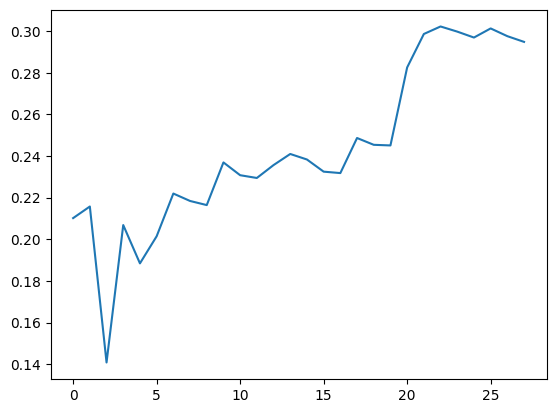

In [10]:
plt.plot( silhouette_scores )

In [13]:
np.argmax(silhouette_scores)

np.int64(22)

Alkūnės metodas: alkūnė, nuo kurios inercija (atstumų suma) nemažėja

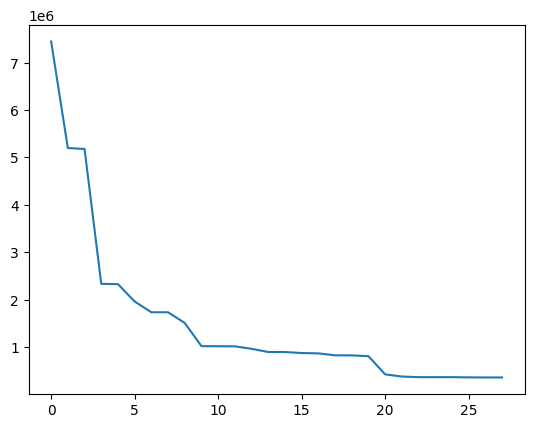

In [12]:
plt.plot(inertia_scores)

Empirinis metodas: $\sqrt{ \frac{\mathrm{steb.\ skaic}}{2} }$

In [15]:
np.sqrt(distance_matrix.shape[0] / 2)

np.float64(19.364916731037084)

> Pagal vidutinį Siluetą - geriausias 22 (nes po to stabilizuojasi/tik mažėja), gal alkūnės metodą - 7, pagal empirinį metodą - 20